In [1]:
from typing import TypedDict, List, Dict, Literal
from pydantic import BaseModel, Field

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

In [2]:
from langchain_ollama import ChatOllama

In [3]:
llm = ChatOllama(
   base_url="http://host.docker.internal:11434", # 원격 서버 주소
   model="gemma4:31b-mlx",
   temperature=0.2,
   reasoning=True
)


In [4]:
class RouteClassification(BaseModel):
    kewy : List[str] = Field(description="중요 키워드 순서대로 출력")

parser = PydanticOutputParser(pydantic_object=RouteClassification)
classifier_prompt = PromptTemplate(
    template="""
사용자가 입력한 질문에서 arxiv에서 검색할 키워드를 추출한다. \n\n
{format_instructions}\n\n
어떠한 부가 설명도 하지 마십시오. \n\n
텍스트: {text}
""",
    input_variables=["text"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)

In [5]:
classifier_chain = classifier_prompt | llm | parser

In [27]:
classifier_chain.invoke("""최근 금융 시장에서 트랜스포머 아키텍처를 활용한 사례가 있는지 알고 싶어.""")


RouteClassification(kewy=['Transformer architecture', 'financial market'])

In [6]:
from langgraph.graph import StateGraph, START, END

In [7]:
class ArxivState(TypedDict):
    input_query : str = Field(description="사용자가 질의한 내용")
    keyword : list[str] = Field(description="llm 사용자의 요청에 따른 키워드 추출", examples=["위고비", "약"])
    category : str = Field(description="사용자 입력한 분야에 대한 category")
    search_result : List[Dict] = Field(description="검색된 결과를 딕셔너리로 하여 여러 결과를 한 리스트에 묶는다.")
    summary_list : list[str] = Field(description="다운로드 받은 논문 요약")
    report : str = Field(description="llm이 최종 결과를 만든 보고서")

In [8]:
class Keyword(BaseModel):
    keyword : List[str] = Field(description="사용자가 입력한 질문에서 중요 키워드를 영어로 출력")
    category : Literal['physics', 'math', 'q-bio', 'cs', 'q-fin', 'stat', 'eess', 'econ'] = Field(description="카테고리 중 사용자의 입력과 유사한 카테고리를 선택")

def keyword_extract_node(state : ArxivState) -> dict:
    parser = PydanticOutputParser(pydantic_object=Keyword)
    keyword_prompt = PromptTemplate(
        template="사용자가 입력한 질문에서 arxiv에서 검색할 키워드를 추출하고 사용자의 질문과 유사한 카테고리를 두가지 이내로 고른다. \n\n{format_instructions}\n\n어떠한 부가 설명도 하지 마십시오.\n\n텍스트: {text}",
        input_variables=["text"],
        partial_variables={"format_instructions": parser.get_format_instructions()},
    )
    classifier_chain = keyword_prompt | llm |  parser
    result = classifier_chain.invoke(state['input_query'])
    return {'keyword' : result.keyword, 'category': result.category}

In [31]:
agent = StateGraph(ArxivState)

In [33]:
agent.add_node("keyword_extract", keyword_extract_node)

In [34]:
agent.add_edge(START, "keyword_extract")
agent.add_edge("keyword_extract", END)
myagent = agent.compile()


In [47]:
rt = myagent.invoke({'input_query' : "최신 다이어트 약 성분과 그 효과에 대한 논문을 찾고 싶어"})['keyword']

In [48]:
rt

['weight loss medication', 'diet drug ingredients', 'anti-obesity drugs']

In [49]:
", ".join(rt)

'weight loss medication, diet drug ingredients, anti-obesity drugs'

In [16]:
import requests
from bs4 import BeautifulSoup

In [59]:
url = "https://arxiv.org/search/physics?query=transformer+attention&searchtype=all&abstracts=show&order=-announced_date_first&size=50"
r = requests.get(url)
bs = BeautifulSoup(r.text)

In [66]:
arxiv_results = bs.find('ol', class_="breathe-horizontal").find_all('li', {'class' : 'arxiv-result'})

In [ ]:
# format
{
    'title': str,
    'author': List[str],
    'abstract': str,
    'pdf_url': str

}

results = []

for paper in arxiv_results:
    res = []
    res.append(paper.find('p', class_="title is-5 mathjax").text.strip())
    res.append(" ".join([y.text for y in paper.find("p", {'class' : 'authors'}).find_all('a')]))
    res.append(paper.find('span', class_="abstract-full has-text-grey-dark mathjax").text.strip().replace("△ Less", ""))
    print(*res)
    break


PRIMS: Physics-guided Representation for Fluid Identification in Multimodal Sensing Hai-Long Nguyen Trung Thanh Nguyen Lars Holm Dennis Alveringh Duc Viet Le Accurate on-device fluid identification is essential for microfluidic applications, yet maintaining reliability under varying flow, pressure, and temperature remains a key challenge. Existing learning-based methods often treat sensor signals as domain-agnostic features, neglecting the underlying physical relationships that govern fluid behavior, thereby limiting generalization and interpretability. To address this, we propose PRIMS, a physics-aware multimodal Transformer that integrates physical knowledge into representation learning and attention mechanisms through three dedicated modules: (1) Physics-based Token Vectorization transforms raw Coriolis and pressure sensor signals into physically meaningful token embeddings; (2) Physical Component Synthesizer models viscosity-related dependencies among flow, pressure, and density; a

In [85]:
url

'https://arxiv.org/search/physics?query=transformer+attention&searchtype=all&abstracts=show&order=-announced_date_first&size=50'

In [19]:
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse, quote, unquote, urljoin


In [ ]:
tmp1 = parse_qs(url.split("?")[-1])


In [146]:
tmp1

'query=bio&searchtype=all&abstracts=show&order=-announced_date_first&size=50'

In [36]:
def get_urls(keywords: List[str], category: str) -> List[str]:
    url = 'https://arxiv.org/search/{}?'.format(category)
    source = {
        'query': [],
        'searchtype': ['all'],
        'abstracts': ['show'],
        'order': ['-announced_date_first'],
        'size': ['25']
    }

    res = []
    for keyword in keywords:
        keyword.replace(" ", "+")
        source['query'] = keyword
        res.append(url + urlencode(source, doseq=True))
    return res


In [21]:
from urllib.request import urlretrieve

def get_papers(urls: List[str], save: bool = False) -> List[Dict]:
    results = []

    for url in urls:
        r = requests.get(url)
        bs = BeautifulSoup(r.text)
        try:
            arxiv_results = bs.find('ol', class_="breathe-horizontal").find_all('li', {'class' : 'arxiv-result'})
        except Exception as e:
            return e + url
        
        for paper in arxiv_results:
            res = {}
            res['title'] = paper.find('p', class_="title is-5 mathjax").text.strip()
            res['author'] = " ".join([y.text for y in paper.find("p", {'class' : 'authors'}).find_all('a')])
            res['abstract'] = paper.find('span', class_="abstract-full has-text-grey-dark mathjax").text.strip().replace("△ Less", "")
            res['pdf_url'] = 'https://arxiv.org/pdf/' + paper.find('div', class_="is-marginless").text.split(':')[1].split('\n')[0]

            if save:
                urlretrieve(res['pdf_url'], f'./saved/arxiv_{res['title']}.pdf')
            results.append(res)

    return results


In [22]:
def paper_extract_node(state : ArxivState) -> List[Dict]:
    keywords = state['keyword']
    category = state['category']
    return {'search_result':  get_papers(get_urls(keywords, category))}

In [23]:
agent = StateGraph(ArxivState)

In [24]:
agent.add_node("paper_extract", paper_extract_node)
agent.add_node("keyword_extract", keyword_extract_node)
agent.add_edge(START, 'keyword_extract')
agent.add_edge("keyword_extract", "paper_extract")
agent.add_edge("paper_extract", END)
myagent = agent.compile()

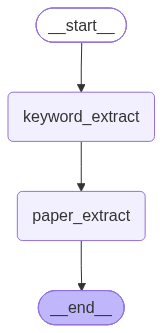

In [25]:
myagent

In [26]:
rt = myagent.invoke({'input_query' : "최신 다이어트 약 성분과 그 효과에 대한 논문을 찾고 싶어"})

['https://arxiv.org/search/q-bio?query=diet+drugs&searchtype=all&abstracts=show&order=-announced_date_first&size=25', 'https://arxiv.org/search/q-bio?query=weight+loss+medication&searchtype=all&abstracts=show&order=-announced_date_first&size=25', 'https://arxiv.org/search/q-bio?query=ingredients&searchtype=all&abstracts=show&order=-announced_date_first&size=25', 'https://arxiv.org/search/q-bio?query=efficacy&searchtype=all&abstracts=show&order=-announced_date_first&size=25']


In [27]:
rt['search_result'][25]

{'title': 'Integrated Information Theory: A Consciousness-First Approach to What Exists',
 'author': 'Giulio Tononi Melanie Boly',
 'abstract': 'This overview of integrated information theory (IIT) emphasizes IIT\'s "consciousness-first" approach to what exists. Consciousness demonstrates to each of us that something exists--experience--and reveals its essential properties--the axioms of phenomenal existence. IIT formulates these properties operationally, yielding the postulates of physical existence. To exist intrinsically or absolutely, an entity must have cause-effect power upon itself, in a specific, unitary, definite and structured manner. IIT\'s explanatory identity claims that an entity\'s cause-effect structure accounts for all properties of an experience--essential and accidental--with no additional ingredients. These include the feeling of spatial extendedness, temporal flow, of objects binding general concepts with particular configurations of features, and of qualia such as

In [28]:
rt.get("search_result")[0]['pdf_url']

'https://arxiv.org/pdf/2507.07604'

In [29]:
from urllib.request import urlretrieve
import os 
target_fol = "./papers"
os.makedirs(target_fol,  exist_ok=True)
file_url = rt.get("search_result")[0]['pdf_url']
urlretrieve(file_url, f'{target_fol}/{file_url.split("/")[-1]}.pdf')


('./papers/2507.07604.pdf', <http.client.HTTPMessage at 0xffff6c41a090>)

In [31]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("./papers/2507.07604.pdf")
documents = loader.load()


In [32]:
class summary(BaseModel):
    summary : str = Field(description="주어진 논문에 대해서 요약을 300자 이내로 요약할 것")



In [33]:
from langchain_core.prompts import ChatPromptTemplate
parser = PydanticOutputParser(pydantic_object=summary)
summary_prompt = PromptTemplate(
    template="주어진 논문을 요약하는 AI입니다. 핵심이 잘 포함되도록 요약할 것 \n\n{format_instructions}\n\n\n\n텍스트: {context}",
    input_variables=["context"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)
summary_chain = summary_prompt | llm |  parser


In [34]:
article = "\n\n".join([x.page_content for x in documents])

In [35]:
document_results = summary_chain.invoke({'context' : article})

In [37]:
document_results

summary(summary='본 논문은 IoBNT 기반의 합성 분자 통신을 이용해 장-뇌 축(GBA)을 간접 조절함으로써 신경계 질환을 치료하는 프레임워크를 제안합니다. 랜덤 포레스트 모델로 케토제닉 식단 등 식이 요법이 장내 미생물과 대사 경로에 미치는 영향을 분석하여, 데이터 기반의 개인 맞춤형 GBA 치료 가능성을 입증했습니다.')